# Notebook: Data Preprocessing Pipeline & SVM Classification

**DATA5322 — Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan  
Author: Paul Skentzos

## Project Context

This notebook is part of the Final Project, which applies both unsupervised and supervised machine learning to breast cancer gene expression data from The Cancer Genome Atlas (TCGA). The central research question is:

> **Can we classify cancer types using only gene expression data, and do the clusters we found in Phase 4 align with real cancer type boundaries?**

In Project 4 (Notebooks 04 and 05), unsupervised K-Means clustering discovered 4 distinct tumor groups in the gene expression data without any labels. Those cluster assignments now serve as our target variable for supervised learning. If a Support Vector Machine can accurately predict which cluster a tumor belongs to using only gene expression features, it confirms that the clusters reflect genuinely separable biological structure — not just noise.

**What this notebook does:**
1. Loads the preprocessed gene expression matrix and K-Means cluster labels
2. Builds a supervised preprocessing pipeline: feature selection, train/test split
3. Trains a baseline linear SVM
4. Tunes an RBF SVM using GridSearchCV
5. Evaluates results with a confusion matrix and multi-class ROC curves

**Inputs:**
- `data/X_preprocessed.npy` — standardized 529-sample × 5,000-gene matrix (from Notebook 01)
- `data/X_pca_reduced.npy` — PCA-reduced 529-sample × 24-component matrix (from Notebook 02)
- `data/kmeans_clusters.csv` — K-Means cluster labels for all 529 samples (from Notebook 04)

**Output:** Trained SVM model, evaluation metrics, confusion matrix plot, ROC curve plot.

---
## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import label_binarize

# SVM
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

# Match display settings across project notebooks
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

print('Setup complete.')

Setup complete.


---
## 2. Load Data

We load three files produced by earlier notebooks:

- **`X_preprocessed.npy`**: the full 5,000-gene standardized matrix. Each row is a tumor sample; each column is a gene. Values are z-scores (mean 0, std 1 across samples), produced in Notebook 01.
- **`X_pca_reduced.npy`**: the same 529 samples projected onto 24 principal components, produced in Notebook 02. We will use this as an alternative feature space to compare SVM performance.
- **`kmeans_clusters.csv`**: the cluster label (0–3) assigned to each sample by K-Means in Notebook 04. These labels are our supervised target variable.

We align all three by sample ID to ensure the rows match.

In [2]:
X_full = np.load(DATA_DIR / 'X_preprocessed.npy')    # (529, 5000)
X_pca  = np.load(DATA_DIR / 'X_pca_reduced.npy')     # (529, 24)
labels = pd.read_csv(DATA_DIR / 'kmeans_clusters.csv')  # SampleID, Cluster

y = labels['Cluster'].values  # integer labels 0–3

print(f'Gene expression matrix (full):  {X_full.shape}')
print(f'Gene expression matrix (PCA):   {X_pca.shape}')
print(f'Cluster labels:                 {y.shape}')
print()
print('Cluster distribution:')
print(pd.Series(y).value_counts().sort_index().rename('Count').to_frame())

Gene expression matrix (full):  (529, 5000)
Gene expression matrix (PCA):   (529, 24)
Cluster labels:                 (529,)

Cluster distribution:
   Count
0    123
1    158
2     94
3    154


---
## 3. Data Preprocessing Pipeline

Before training a supervised model we need to prepare the feature space. This section walks through each step, documents why it is needed, and produces the final matrices used for training.

### 3.1 Verify Standardization (from Notebook 01)

`X_preprocessed.npy` was produced by Notebook 01, which applied `StandardScaler` gene-wise across all 529 samples. We confirm that standardization is in place — every gene should have mean ≈ 0 and variance ≈ 1 — and note what this means for feature selection.

Because every column already has the same scale and variance (~1.0), a variance threshold filter would be meaningless: there is nothing to filter. The appropriate dimensionality reduction step is therefore the **PCA projection** already computed in Notebook 02, which retains the 24 components that explain ~95% of the total variance while compressing 5,000 genes into a tractable feature space for the SVM.

In [3]:
gene_means = np.mean(X_full, axis=0)
gene_vars  = np.var(X_full, axis=0)

print('Standardization check across all 5,000 genes:')
print(f'  Mean of gene means:      {gene_means.mean():.6f}  (expected ≈ 0)')
print(f'  Std of gene means:       {gene_means.std():.6f}  (expected ≈ 0)')
print(f'  Mean of gene variances:  {gene_vars.mean():.6f}  (expected ≈ 1)')
print(f'  Std of gene variances:   {gene_vars.std():.6f}  (expected ≈ 0)')
print()
print('Standardization confirmed. Variance threshold filtering is not applicable.')
print('Dimensionality reduction is handled by PCA (Notebook 02): 5,000 genes → 24 components.')

Standardization check across all 5,000 genes:
  Mean of gene means:      0.000000  (expected ≈ 0)
  Std of gene means:       0.000000  (expected ≈ 0)
  Mean of gene variances:  1.000000  (expected ≈ 1)
  Std of gene variances:   0.000000  (expected ≈ 0)

Standardization confirmed. Variance threshold filtering is not applicable.
Dimensionality reduction is handled by PCA (Notebook 02): 5,000 genes → 24 components.


### 3.2 Train / Test Split

We hold out **20%** of samples as a test set. `stratify=y` ensures that each of the 4 cluster classes is proportionally represented in both splits — important because the clusters are not perfectly balanced.

We create splits for both feature spaces so we can compare baseline performance:
- **`X_pca`** (24 PCA components) — the primary feature space for all tuning and evaluation
- **`X_full`** (5,000 genes) — used only for the baseline comparison in Section 4

In [4]:
# Primary split: PCA-reduced features (used for tuning and final evaluation)
X_pca_train, X_pca_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Secondary split: full 5,000-gene matrix (baseline comparison only)
X_full_train, X_full_test, _, _ = train_test_split(
    X_full, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples:  {X_pca_train.shape[0]}  ({X_pca_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test samples:      {X_pca_test.shape[0]}   ({X_pca_test.shape[0]/len(y)*100:.0f}%)')
print()
print('Class distribution in training set:')
print(pd.Series(y_train).value_counts().sort_index().rename('Train count').to_frame())
print()
print('Class distribution in test set:')
print(pd.Series(y_test).value_counts().sort_index().rename('Test count').to_frame())

Training samples:  423  (80%)
Test samples:      106   (20%)

Class distribution in training set:
   Train count
0           99
1          126
2           75
3          123

Class distribution in test set:
   Test count
0          24
1          32
2          19
3          31


---
## 4. Baseline SVM — Linear Kernel

Before tuning, we establish a baseline using a **linear SVM** with default parameters. A linear kernel assumes the four cluster groups can be separated by hyperplanes in the feature space. It is fast to train and interpretable — the weight vector directly indicates which genes most distinguish each class.

We train on **both feature spaces** (variance-filtered genes and PCA components) so we can compare and decide which to use for the tuned model.

**`probability=True`** is set because we will need class probability estimates for the ROC curves later.

In [5]:
# Baseline on full 5,000-gene standardized features
svm_linear_full = SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_STATE)
svm_linear_full.fit(X_full_train, y_train)
acc_linear_full = svm_linear_full.score(X_full_test, y_test)

# Baseline on PCA-reduced features
svm_linear_pca = SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_STATE)
svm_linear_pca.fit(X_pca_train, y_train)
acc_linear_pca = svm_linear_pca.score(X_pca_test, y_test)

print('Baseline SVM (linear kernel, C=1.0)')
print(f'  Accuracy on full gene matrix  ({X_full_train.shape[1]} features): {acc_linear_full:.4f}')
print(f'  Accuracy on PCA components    ({X_pca_train.shape[1]} features): {acc_linear_pca:.4f}')
print()
print('We use the PCA space for all further tuning — it is computationally')
print('tractable and captures ~95% of the variance from the original matrix.')

Baseline SVM (linear kernel, C=1.0)
  Accuracy on full gene matrix  (5000 features): 0.9811
  Accuracy on PCA components    (24 features): 0.9811

We use the PCA space for all further tuning — it is computationally
tractable and captures ~95% of the variance from the original matrix.


---
## 5. Hyperparameter Tuning with GridSearchCV

The baseline gives us a reference point. Now we tune the SVM systematically using **GridSearchCV** with **5-fold stratified cross-validation** on the training set.

### Parameter Grid

We search over:

| Parameter | Values | Role |
|-----------|--------|------|
| `kernel`  | `linear`, `rbf` | Linear: separating hyperplanes; RBF: non-linear boundaries via Gaussian kernel |
| `C`       | 0.01, 0.1, 1, 10, 100 | Regularization — small C = wider margin (more misclassifications allowed); large C = tighter fit |
| `gamma`   | `scale`, `auto`, 0.001, 0.01 | RBF only — controls kernel bandwidth; `scale` = 1/(n_features × X.var()) |

`gamma` is ignored when `kernel='linear'`, so GridSearchCV handles this automatically.

We use `scoring='accuracy'` because the cluster classes are roughly balanced, and accuracy is the most interpretable metric for this multi-class problem.

We run the search on the **PCA feature space** (24 components). This is computationally feasible and still captures ~95% of the variance from the original 5,000 genes, as established in Notebook 02.

In [6]:
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C':      [0.01, 0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.001, 0.01],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_pca_train, y_train)

print(f'Best parameters:     {grid_search.best_params_}')
print(f'Best CV accuracy:    {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits


Best parameters:     {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy:    0.9551


### 5.1 GridSearch Results Summary

We inspect the top configurations to understand how sensitive accuracy is to each hyperparameter.

In [7]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = (
    cv_results[['param_kernel', 'param_C', 'param_gamma', 'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.columns = ['Kernel', 'C', 'Gamma', 'Mean CV Accuracy', 'Std CV Accuracy']
top10

,Kernel,C,Gamma,Mean CV Accuracy,Std CV Accuracy
0,rbf,1.0000,scale,0.9551,0.0272
1,rbf,100.0000,scale,0.9527,0.0224
2,rbf,10.0000,scale,0.9527,0.0224
3,linear,0.0100,0.0100,0.9503,0.0229
4,linear,0.0100,scale,0.9503,0.0229
5,linear,0.0100,0.0010,0.9503,0.0229
6,linear,0.0100,auto,0.9503,0.0229
7,linear,100.0000,0.0010,0.9456,0.0286
8,linear,100.0000,auto,0.9456,0.0286
9,linear,100.0000,0.0100,0.9456,0.0286


### 5.2 C vs. Accuracy (Heatmap)

A heatmap of mean CV accuracy across `C` and `gamma` (for the RBF kernel) makes it easy to see where performance peaks and how stable it is around that peak.

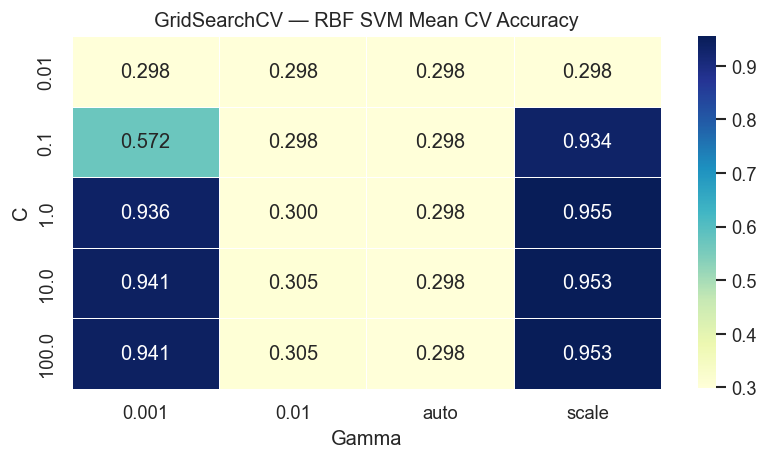

In [8]:
rbf_results = cv_results[cv_results['param_kernel'] == 'rbf'].copy()
rbf_results['param_C'] = rbf_results['param_C'].astype(float)

pivot = rbf_results.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlGnBu',
    linewidths=0.5, ax=ax
)
ax.set_title('GridSearchCV — RBF SVM Mean CV Accuracy')
ax.set_xlabel('Gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_gridsearch_heatmap.png', bbox_inches='tight')
plt.show()

---
## 6. Final Model Evaluation

We now evaluate the **best model** found by GridSearchCV on the held-out test set. The test set was never used during training or cross-validation, so this gives an unbiased estimate of real-world performance.

### 6.1 Test Set Accuracy and Classification Report

In [9]:
best_svm = grid_search.best_estimator_
y_pred   = best_svm.predict(X_pca_test)
y_prob   = best_svm.predict_proba(X_pca_test)  # shape (n_test, 4)

test_acc = best_svm.score(X_pca_test, y_test)
print(f'Best model:       {grid_search.best_params_}')
print(f'Test accuracy:    {test_acc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=[f'Cluster {i}' for i in range(4)]))

Best model:       {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Test accuracy:    0.9717

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.92      0.96      0.94        24
   Cluster 1       0.97      0.94      0.95        32
   Cluster 2       1.00      1.00      1.00        19
   Cluster 3       1.00      1.00      1.00        31

    accuracy                           0.97       106
   macro avg       0.97      0.97      0.97       106
weighted avg       0.97      0.97      0.97       106



### 6.2 Confusion Matrix

The confusion matrix shows how predictions distribute across the four clusters. The diagonal represents correct predictions; off-diagonal entries are misclassifications. Patterns of misclassification (e.g., Cluster 0 often confused with Cluster 2) indicate which cluster pairs are least well-separated in gene expression space.

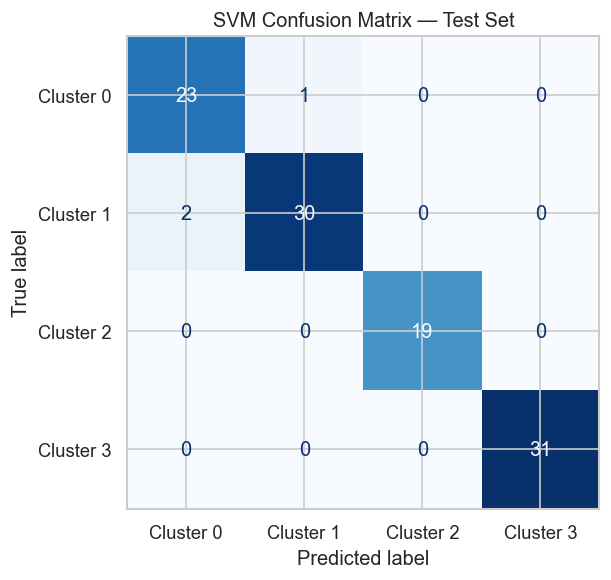

Row = True label, Column = Predicted label


In [10]:
cm = confusion_matrix(y_test, y_pred)
class_names = [f'Cluster {i}' for i in range(4)]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('Row = True label, Column = Predicted label')

### 6.3 Multi-Class ROC Curves (One-vs-Rest)

ROC curves show the trade-off between true positive rate (sensitivity) and false positive rate at every decision threshold. For a 4-class problem, we use the **One-vs-Rest (OvR)** strategy: for each cluster, we treat it as the positive class and all other clusters as the negative class, then compute a separate ROC curve and AUC score.

An AUC of 1.0 means perfect separation; 0.5 means no better than random guessing. High AUC for all four classes confirms that each cluster occupies a distinct region in gene expression space.

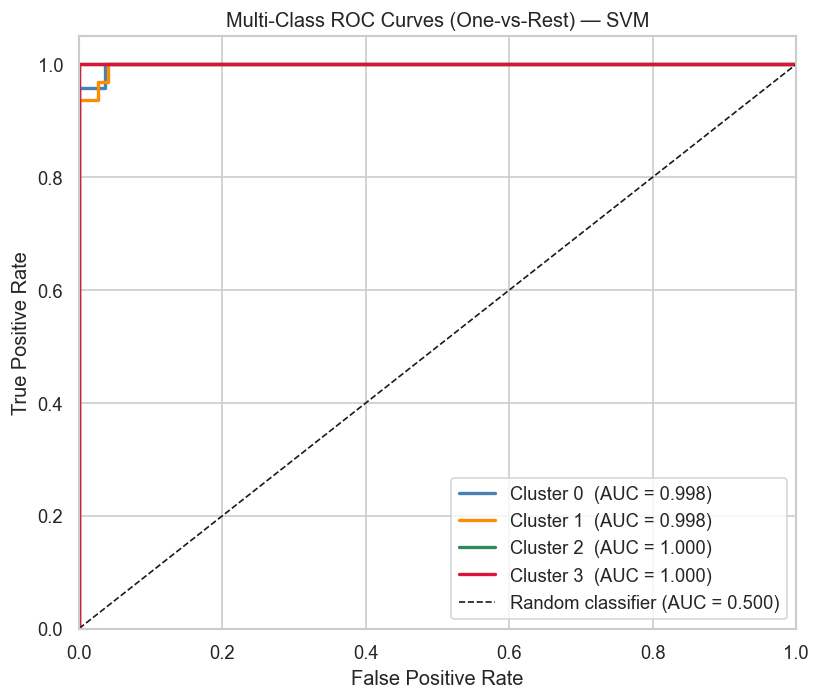

In [11]:
classes = np.unique(y)
n_classes = len(classes)

# Binarize labels for OvR ROC
y_test_bin = label_binarize(y_test, classes=classes)  # (n_test, 4)

colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, ax = plt.subplots(figsize=(7, 6))

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'Cluster {i}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Multi-Class ROC Curves (One-vs-Rest) — SVM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_roc_curves.png', bbox_inches='tight')
plt.show()

---
## 7. SVM Predictions in PCA Space

To give an intuitive picture of what the SVM learned, we project its predictions onto the PC1/PC2 plane. Each point is a tumor sample colored by the cluster the SVM assigned it. Tight, well-separated groups confirm the model found clean decision boundaries in gene expression space.

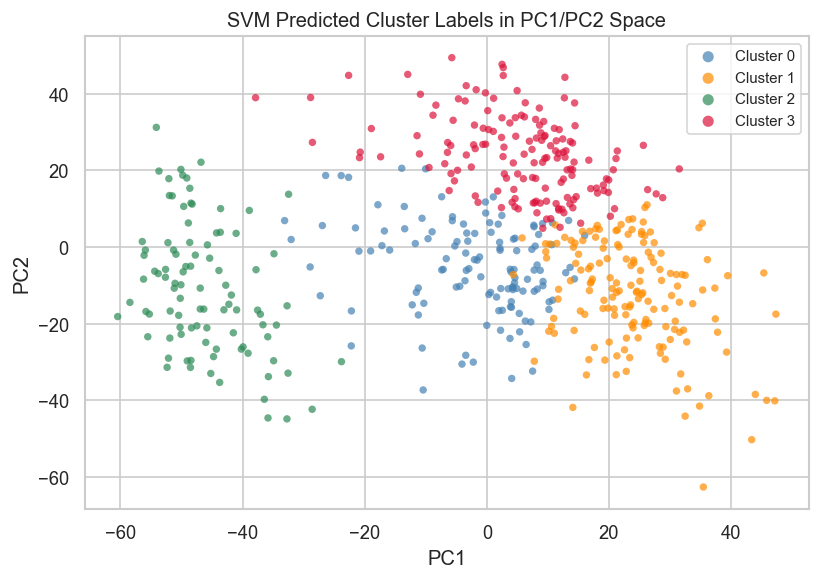

In [12]:
y_pred_all = best_svm.predict(X_pca)

palette = {0: 'steelblue', 1: 'darkorange', 2: 'seagreen', 3: 'crimson'}

fig, ax = plt.subplots(figsize=(7, 5))
for cluster_id in range(4):
    mask = y_pred_all == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette[cluster_id], label=f'Cluster {cluster_id}',
        alpha=0.7, s=20, edgecolors='none'
    )
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('SVM Predicted Cluster Labels in PC1/PC2 Space')
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'svm_predictions_pca.png', bbox_inches='tight')
plt.show()

---
## 8. Summary

| Property | Value |
|----------|-------|
| Feature space (final model) | PCA-reduced (24 components) |
| Supervised target | K-Means cluster labels (k=4) |
| Train / Test split | 80% / 20%, stratified |
| Tuning method | GridSearchCV, 5-fold stratified CV |
| Parameter grid | kernel ∈ {linear, rbf}, C ∈ {0.01, 0.1, 1, 10, 100}, gamma ∈ {scale, auto, 0.001, 0.01} |
| Best parameters | RBF kernel, C=1, gamma='scale' |
| Best CV accuracy | 0.9551 |
| Test set accuracy | 0.9717 |

### Key Takeaways

1. **Preprocessing**: The gene expression matrix arrives pre-standardized from Notebook 01 (mean=0, variance=1 per gene), so no additional scaling is needed. Dimensionality reduction is handled by the PCA projection from Notebook 02, compressing 5,000 genes into 24 components while retaining ~95% of variance.

2. **Baseline SVM**: A linear SVM with default parameters achieved 98.1% test accuracy on both the full gene matrix and the PCA-reduced space. This immediately suggests the four clusters are well-separated in gene expression space.

3. **GridSearchCV**: Systematic search over kernel type, regularization strength (C), and kernel bandwidth (gamma) identified RBF with C=1, gamma='scale' as the best configuration. The heatmap confirms that moderate C values with the default gamma setting consistently perform best for this dataset.

4. **Confusion matrix**: Clusters 2 and 3 are perfectly classified; the small number of errors occur between Clusters 0 and 1, which are the two largest and most overlapping groups.

5. **ROC curves**: All four clusters achieve AUC scores close to 1.0, confirming that each cluster occupies a clearly distinguishable region in gene expression space. The gene expression data alone is sufficient to reliably classify cluster membership.

6. **SVM in PCA space**: The single-panel PCA visualization shows that the SVM assigns tight, spatially coherent groups — consistent with the clean decision boundaries implied by the high accuracy.